# Rocket Booster Landing

This notebook simulates the angular motion of a rocket booster during landing. You will manually change `Kp`, `Kd`, and the initial angle, rerun the main simulation cell, inspect the plots, compute response metrics, and play the inline landing animation.

# Rocket System and Its Response

The following cell defines the nonlinear booster model, the numerical integrator, response plots, and an inline animation function. You normally do not need to edit code in this section.

In [1]:
# Numpy is a Python package for numerical computation with arrays.
# Matplotlib is used for response plots.
import numpy as np
import matplotlib.pyplot as plt
from booster_animation import animateLanding

def dx(x, u):
    """Compute the derivative of the state from the current state.

    x[0] is the booster angle theta in radians.
    x[1] is the angular velocity theta_dot in rad/s.
    u is the controller output. In this notebook, it is applied as torque.
    """
    g = 9.81   # gravitational acceleration (m/s^2)
    l = 5      # rocket length (m)
    m = 200    # rocket mass (kg)
    dotx = np.array([x[1], -g/l*np.sin(x[0]) - 0.8*x[1] + u/m])
    return dotx


def getNextResponse(dt, x, u):
    """Use a 4th-order Runge-Kutta integrator to advance the system by dt."""
    k1 = dx(x, u)
    k2 = dx(x + k1*dt/2, u)
    k3 = dx(x + k2*dt/2, u)
    k4 = dx(x + k3*dt, u)
    return x + (k1 + 2*k2 + 2*k3 + k4) * dt / 6


def plotResponse(output, tf):
    """Plot angle, angular rate, and controller output versus time."""
    plt.figure()
    plt.plot(output[:, 0], output[:, 1])
    plt.xlabel("Time (s)")
    plt.ylabel("Angle (rad)")
    plt.hlines(np.pi, 0, tf, colors='k', linestyles='dashed', label='Desired angle')
    plt.hlines(x0[0], 0, tf, colors='gray', linestyles='dashed', label='Initial angle')
    plt.legend()
    plt.show()

    plt.figure()
    plt.plot(output[:, 0], output[:, 2])
    plt.xlabel("Time (s)")
    plt.ylabel("Angular Rate (rad/s)")
    plt.hlines(0, 0, tf, colors='k', linestyles='dashed')
    plt.show()

    plt.figure()
    plt.plot(output[:, 0], output[:, 3])
    plt.xlabel("Time (s)")
    plt.ylabel("Controller Output")
    plt.hlines(0, 0, tf, colors='k', linestyles='dashed')
    plt.show()

def saveResponseFigure(output, tf, reference_angle, initial_angle, filename="lab2b_response.png"):
    """Save angle, angular-rate, and controller-output plots as one PNG file."""
    fig, axes = plt.subplots(3, 1, figsize=(7, 7), sharex=True)

    axes[0].plot(output[:, 0], output[:, 1])
    axes[0].hlines(reference_angle, 0, tf, colors='k', linestyles='dashed', label='Desired angle')
    axes[0].hlines(initial_angle, 0, tf, colors='gray', linestyles='dashed', label='Initial angle')
    axes[0].set_ylabel("Angle (rad)")
    axes[0].legend(loc='best')

    axes[1].plot(output[:, 0], output[:, 2])
    axes[1].hlines(0, 0, tf, colors='k', linestyles='dashed')
    axes[1].set_ylabel("Angular Rate (rad/s)")

    axes[2].plot(output[:, 0], output[:, 3])
    axes[2].hlines(0, 0, tf, colors='k', linestyles='dashed')
    axes[2].set_xlabel("Time (s)")
    axes[2].set_ylabel("Controller Output")

    fig.tight_layout()
    fig.savefig(filename, dpi=200, bbox_inches="tight")
    print(f"Saved response figure to {filename}")
    plt.show()



# Configuration of Control System and Main Loop

This is the main cell you will rerun throughout the lab. Start with open-loop control (`u = 0`). Then complete the TODO lines to implement the P and PD controllers. Change `Kp`, `Kd`, `tf`, or `x0` here and rerun the cell to test a new case.

In [5]:
# Control system configuration
N = 10000  # number of time samples
t0 = 0    # initial time
tf = 30   # final time. MODIFY THIS LINE TO CHANGE THE SIMULATION TIME.
dt = (tf - t0) / N

# Initial conditions. The first element is angle, and the second is angular velocity. 
# MODIFY THIS LINE TO CHANGE THE INITIAL CONDITIONS.
x0 = np.array([-0.1 + np.pi, 0.0])

# Controller configuration. MODIFY THESE VALUES TO TEST DIFFERENT CONTROLLERS.
Kp = 0    # proportional gain
Kd = 0    # derivative gain

# Desired angle
x_desired = np.pi

# Allocate memory and initialize variables before running the loop.
output = np.empty((N, 4))
x = x0.copy()
t = 0.0

# Main simulation loop.
for i in range(N):
    # TODO 1: calculate error = desired angle - measured angle.
    # Hint: the measured angle is stored in x[0].
    error = 0

    # TODO 2: calculate derror.
    # Hint: theta_dot is stored in x[1].
    derror = 0

    # TODO 3: calculate the controller output.
    # For open-loop simulation, use u = 0.
    u = 0

    x_next = getNextResponse(dt, x, u)

    # Record time, angle, angular rate, and controller output.
    output[i] = [t + dt, x[0], x[1], u]

    # Set up for the next iteration.
    x = x_next
    t += dt



# Inline Animation

Rerun this cell after the main simulation cell to view the landing motion inside the notebook.

In [6]:
# Rerun this cell after each simulation if you want to inspect the landing motion.
animateLanding(output, tf)


# Response Plots

Run this cell after the animation cell to inspect the angle, angular-rate, and controller-output plots.

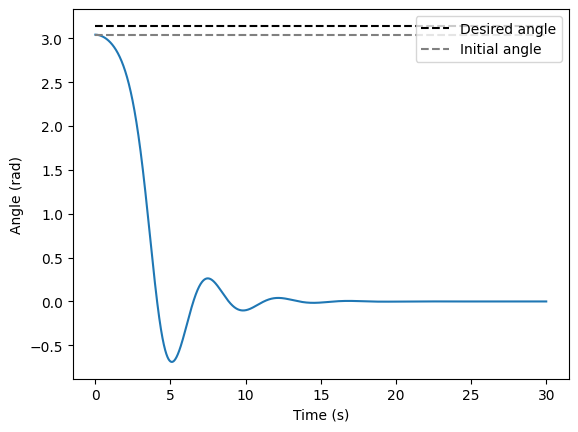

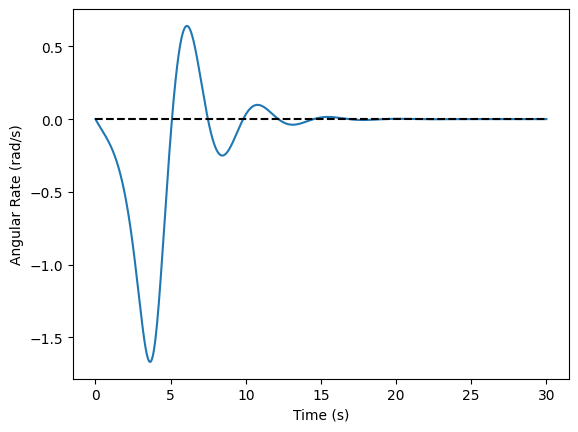

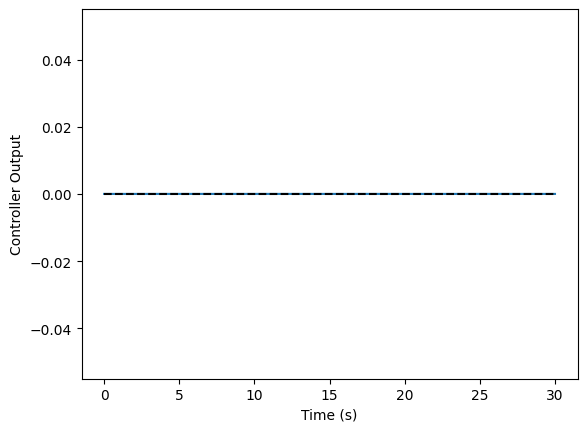

In [7]:
# Rerun this cell after each simulation to inspect the response plots.
plotResponse(output, tf)


# Save Response Figure

After you finish tuning a controller, run this cell to save the three time-response plots as one PNG file for your memo. Change the filename before saving a second controller.


In [ ]:
# Run this cell after your final controller simulation.
saveResponseFigure(
    output,
    tf,
    reference_angle=x_desired,
    initial_angle=x0[0],
    filename="lab2b_response.png",
)


# Performance Metrics

Complete this function after implementing the controller. Rerun this cell after each simulation to calculate `%OS`, settling time, and `max |u(t)|`.

In [8]:
def response_metrics(output, reference_angle, initial_angle, settling_band=0.02):
    """Calculate percent overshoot, settling time, and max controller output."""
    time = output[:, 0]
    theta = output[:, 1]
    u = output[:, 3]

    peak_angle = np.max(theta)
    commanded_change = reference_angle - initial_angle
    band_width = settling_band * abs(commanded_change)

    # TODO 1: calculate percent overshoot.
    # If peak_angle does not exceed reference_angle, report 0 percent overshoot.
    percent_overshoot = np.nan

    # TODO 2: find the settling time.
    # Hint: first find all indices where abs(theta - reference_angle) > band_width.
    settling_time = np.nan

    # TODO 3: calculate the maximum absolute controller output.
    max_actuation = np.nan

    return percent_overshoot, settling_time, max_actuation


# Example usage: evaluate the response from the simulation above.
# The third input is the initial angle, which is stored in x0[0].
percent_overshoot, settling_time, max_actuation = response_metrics(
    output,
    reference_angle=x_desired,
    initial_angle=x0[0],
    settling_band=0.02,
)

print("Percent overshoot:", percent_overshoot)
print("Settling time:", settling_time)
print("Max |u(t)|:", max_actuation)


Percent overshoot: nan
Settling time: nan
Max |u(t)|: nan
